Baseline Perceptron
Accuracy: 0.7962128043282236
Precision: 0.787719298245614
Recall: 0.8104693140794224
F1-score: 0.798932384341637

Decision Tree
Accuracy: 0.7799819657348963
Precision: 0.7818181818181819
Recall: 0.776173285198556
F1-score: 0.7789855072463768

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       555
           1       0.78      0.78      0.78       554

    accuracy                           0.78      1109
   macro avg       0.78      0.78      0.78      1109
weighted avg       0.78      0.78      0.78      1109



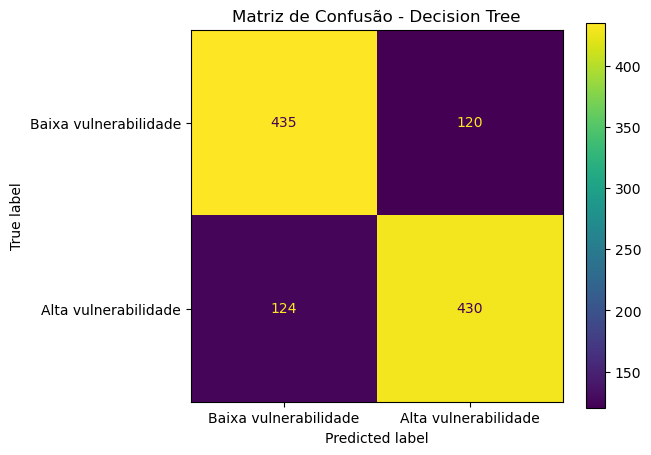

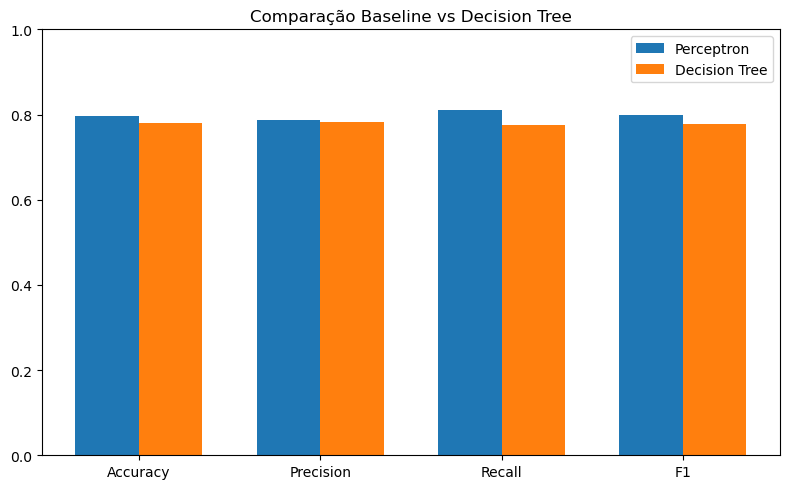

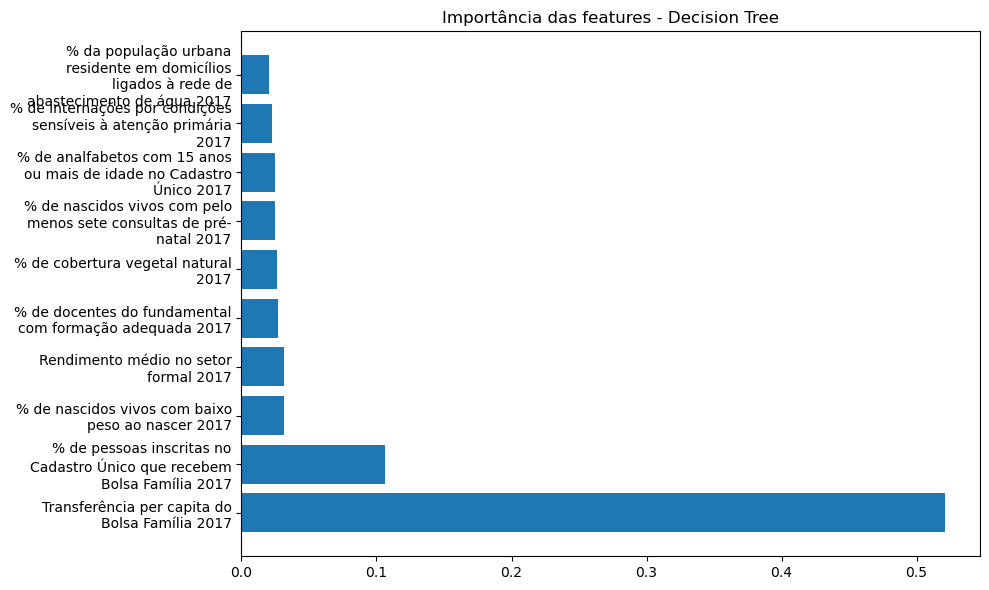

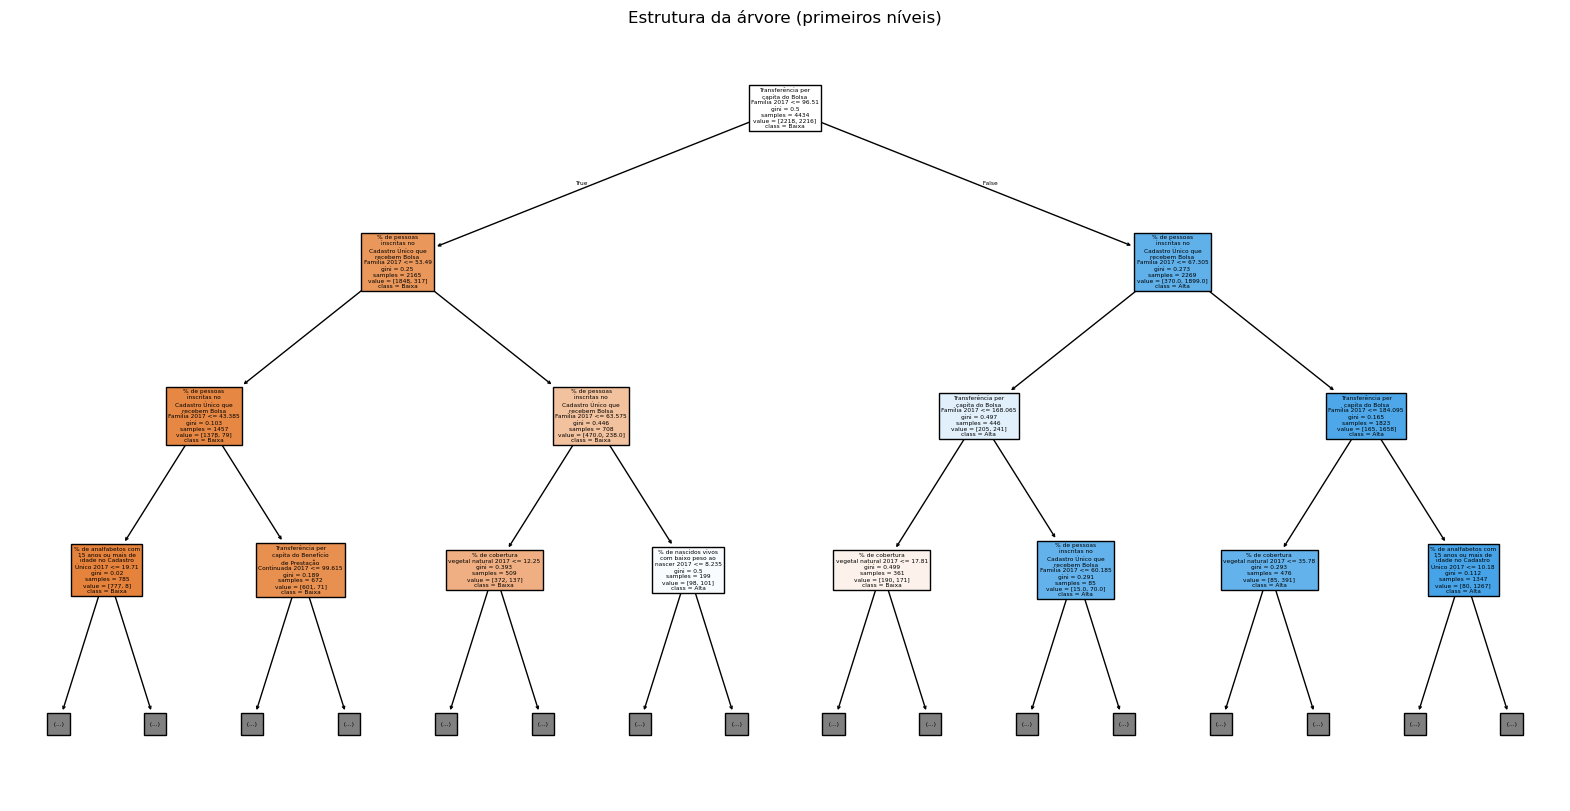


Regras da árvore:
|--- Transferência per capita do Bolsa Família 2017 <= 96.51
|   |--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 <= 53.49
|   |   |--- % de pessoas inscritas no Cadastro Único que recebem Bolsa Família 2017 <= 43.39
|   |   |   |--- % de analfabetos com 15 anos ou mais de idade no Cadastro Único 2017 <= 19.71
|   |   |   |   |--- Transferência per capita do Benefício de Prestação Continuada 2017 <= 5.95
|   |   |   |   |   |--- % da população urbana residente em domicílios ligados à rede de abastecimento de água 2017 <= 99.97
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- % da população urbana residente em domicílios ligados à rede de abastecimento de água 2017 >  99.97
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Transferência per capita do Benefício de Prestação Continuada 2017 >  5.95
|   |   |   |   |   |--- % de analfabetos com 15 anos ou mais de idade no Cadastro Único 2017 <= 3.71
|   |   |   |   |   |

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

CSV_PATH = '../data/censo_municipal.csv'
ID_COL = "Territorialidades"
TARGET_SOURCE_COL = "% de extremamente pobres no Cadastro Único pós Bolsa Família 2017"
TEST_SIZE = 0.20
RANDOM_STATE = 42

def wrap_labels(labels, width=30):
    return [textwrap.fill(label, width) for label in labels]

df = pd.read_csv(CSV_PATH)

for col in df.columns:
    if col != ID_COL:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace("%", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace(["nan", "None", ""], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[TARGET_SOURCE_COL]).copy()

municipios = df[ID_COL].copy()

threshold = df[TARGET_SOURCE_COL].median()
df["vulnerabilidade_alta"] = (df[TARGET_SOURCE_COL] > threshold).astype(int)

drop_cols = [ID_COL, TARGET_SOURCE_COL, "vulnerabilidade_alta"]

X = df.drop(columns=drop_cols).copy()
y = df["vulnerabilidade_alta"].copy()

X = X.select_dtypes(include=[np.number]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("perceptron", Perceptron(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_prec = precision_score(y_test, baseline_pred)
baseline_rec = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)
tree_prec = precision_score(y_test, tree_pred)
tree_rec = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

print("Baseline Perceptron")
print("Accuracy:", baseline_acc)
print("Precision:", baseline_prec)
print("Recall:", baseline_rec)
print("F1-score:", baseline_f1)

print("\nDecision Tree")
print("Accuracy:", tree_acc)
print("Precision:", tree_prec)
print("Recall:", tree_rec)
print("F1-score:", tree_f1)

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, tree_pred))

cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baixa vulnerabilidade","Alta vulnerabilidade"])
disp.plot(ax=plt.gca())
plt.title("Matriz de Confusão - Decision Tree")
plt.grid(False)
plt.show()

metrics_names = ["Accuracy","Precision","Recall","F1"]

baseline_metrics = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
tree_metrics = [tree_acc, tree_prec, tree_rec, tree_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x-width/2, baseline_metrics, width, label="Perceptron")
plt.bar(x+width/2, tree_metrics, width, label="Decision Tree")
plt.xticks(x, metrics_names)
plt.ylim(0,1)
plt.title("Comparação Baseline vs Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

tree = tree_model.named_steps["tree"]

importances = tree.feature_importances_

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top_imp = imp_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(wrap_labels(top_imp["feature"]), top_imp["importance"])
plt.title("Importância das features - Decision Tree")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=wrap_labels(X.columns,20),
    class_names=["Baixa","Alta"],
    filled=True,
    max_depth=3
)
plt.title("Estrutura da árvore (primeiros níveis)")
plt.show()

rules = export_text(tree, feature_names=list(X.columns))

print("\nRegras da árvore:")
print(rules[:2000])

print("\nProfundidade da árvore:", tree.get_depth())
print("Número de folhas:", tree.get_n_leaves())